##### Instructions

Complete every code location marked **`TODO`**. Run the notebook from top to bottom after completing each section.

By the end of this exercise, you should be able to:

1. implement centroid initialization, assignment, and update steps in K-means;
2. calculate distortion and the silhouette score;
3. compare a from-scratch implementation with scikit-learn;
4. implement the E-step and M-step of a Gaussian Mixture Model (GMM);
5. monitor log-likelihood and use it as a convergence criterion.

**Rules:** Do not call `sklearn.cluster.KMeans` inside the from-scratch K-means class, and do not call `sklearn.mixture.GaussianMixture` inside the from-scratch GMM class. Small numerical constants such as `1e-9` may be added when needed for stability.

## a) Clustering using K-means

### Program 1 - Implementing K-means Clustering from scratch and using scikit learn

#### AIM

To implement K-means clustering from scratch, evaluate the resulting clusters, and compare the implementation with scikit-learn.

#### K-means algorithm

1. Select $k$ observations as the initial centroids.
2. Assign every observation to its nearest centroid.
3. Replace each centroid by the mean of the observations assigned to it.
4. Repeat steps 2–3 until the centroids stop changing (or a maximum number of iterations is reached).

#### Distortion

In this exercise, distortion is the mean Euclidean distance between every observation and its assigned centroid:

$$D = \frac{1}{N}\sum_{i=1}^{N}\lVert\mathbf{x}_i-\boldsymbol{\mu}_{z_i}\rVert_2.$$

#### Silhouette score

For observation $i$, let $a(i)$ be its mean distance to the other points in its own cluster and let $b(i)$ be the smallest mean distance from it to any other cluster. Then

$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}, \qquad S=\frac{1}{N}\sum_i s(i).$$

A score near $1$ indicates well-separated clusters, while a score near $-1$ indicates that many observations may be assigned to the wrong cluster.

#### Part 1 - Defining class for KMeans

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.set_printoptions(precision=4, suppress=True)

In [19]:
class KMeans:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, train_x, random_state=0):
        train_x = np.asarray(train_x)
        m = train_x.shape[0]
        if self.n_clusters > m:
            raise ValueError("n_clusters cannot exceed number of observations")
        rng = np.random.default_rng(random_state)


        indices = rng.choice(m, size=self.n_clusters, replace=False)
        self.centroids = train_x[indices].copy()

        for iteration in range(self.max_iter):
            old_centroids = self.centroids.copy()


            distances = cdist(train_x, self.centroids)
            self.labels = np.argmin(distances, axis=1)


            for cluster_id in range(self.n_clusters):
                points = train_x[self.labels == cluster_id]
                if len(points) > 0:
                    self.centroids[cluster_id] = points.mean(axis=0)


            displacement = np.linalg.norm(self.centroids - old_centroids)
            if displacement <= self.tol:
                break

        self.n_iter_ = iteration + 1
        return self

    def predict(self, points):
        points = np.asarray(points)
        distances = cdist(points, self.centroids)
        return np.argmin(distances, axis=1)


#### Part 2 — Defining evaluation metrics

Complete both functions without calling their scikit-learn equivalents. Test the edge cases: a single cluster, a singleton cluster, and more than two clusters.

In [3]:
def distortion(X, labels, centroids):
    X = np.asarray(X)
    labels = np.asarray(labels)
    assigned_centroids = centroids[labels]
    return np.mean(np.linalg.norm(X - assigned_centroids, axis=1))


def silhouette_score(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return 0.0

    distances = cdist(X, X)
    scores = np.zeros(len(X))

    for i in range(len(X)):
        own_cluster = labels[i]
        own_indices = np.where(labels == own_cluster)[0]
        other_indices = own_indices[own_indices != i]


        if len(other_indices) == 0:
            scores[i] = 0.0
            continue

        a_i = distances[i, other_indices].mean()
        b_i = np.inf

        for cluster in unique_labels:
            if cluster == own_cluster:
                continue
            cluster_indices = np.where(labels == cluster)[0]
            mean_distance = distances[i, cluster_indices].mean()
            b_i = min(b_i, mean_distance)

        denominator = max(a_i, b_i)
        scores[i] = 0.0 if denominator == 0 else (b_i - a_i) / denominator

    return scores.mean()


#### Part 3 — Loading the Iris dataset

We use the copy bundled with scikit-learn so that this notebook does not depend on a separate CSV file. The species column is retained only for the later visual comparison; it is not supplied to either clustering algorithm.

In [4]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_df = iris.frame.rename(columns={
    "sepal length (cm)": "s_len",
    "sepal width (cm)": "s_wid",
    "petal length (cm)": "p_len",
    "petal width (cm)": "p_wid",
    "target": "species_code",
})
iris_df["species"] = iris_df["species_code"].map(dict(enumerate(iris.target_names)))
iris_df = iris_df.drop(columns="species_code")
names = ["s_len", "s_wid", "p_len", "p_wid", "species"]

display(iris_df.head())
print(
    f"The dataset contains {iris_df.shape[0]} records and "
    f"{iris_df.shape[1] - 1} numerical features.",
    iris_df["species"].value_counts(),
    sep="\n",
)

,s_len,s_wid,p_len,p_wid,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


The dataset contains 150 records and 4 numerical features.
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


#### Part 4 - Implementing K-means Clustering

In [5]:
train_x = iris_df.drop(columns="species").to_numpy()

# Set k to the number of known Iris species, fit your KMeans model,
# and construct `all_df` for the plotting cell below.
k = iris_df["species"].nunique()
kmeans = KMeans(n_clusters=k, max_iter=300, tol=1e-4)
kmeans.fit(train_x, random_state=0)

assert kmeans is not None, "TODO 8: create and fit the KMeans model"
assert kmeans.centroids.shape == (k, train_x.shape[1])
assert kmeans.labels.shape == (train_x.shape[0],)

all_df = iris_df.copy(deep=True)
centroids = pd.DataFrame(kmeans.centroids, columns=names[:-1])
centroids["cluster"] = "centroid"
all_df["cluster"] = kmeans.labels.astype(str)
all_df = pd.concat([all_df, centroids], ignore_index=True)


#### Part 5 - Comparing the Clustering results with original classes

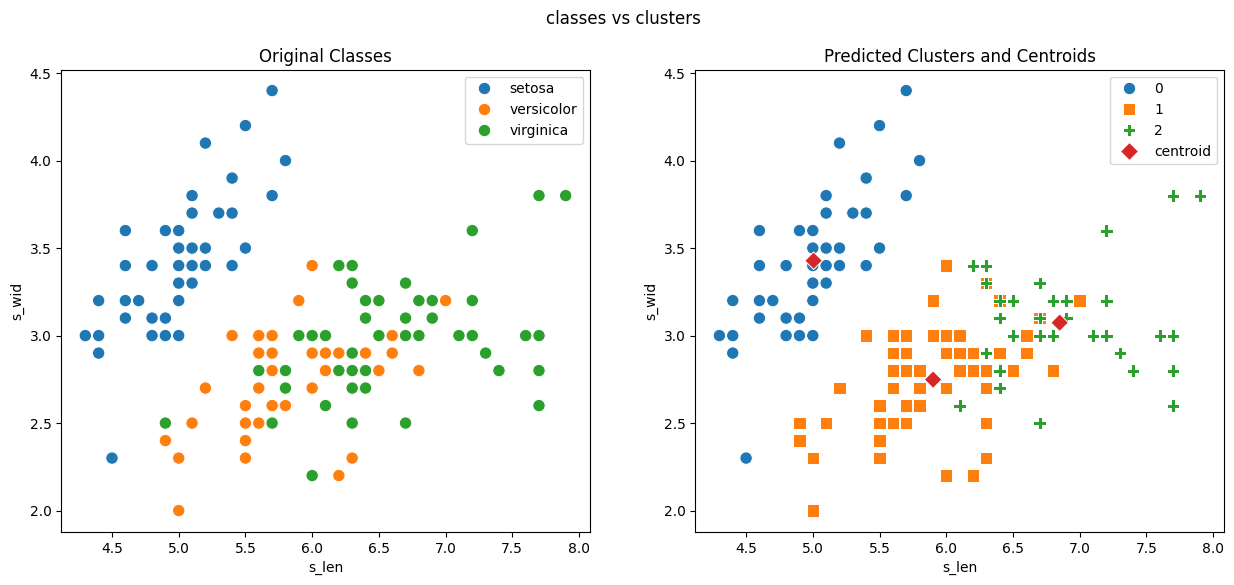

In [6]:
plt.figure(figsize=(15,6))
plt.suptitle("classes vs clusters")
plt.subplot(121)
plt.title("Original Classes")
sns.scatterplot(data=all_df,x="s_len",y="s_wid",hue="species",s=80)
plt.legend(loc="upper right")

plt.subplot(122)
plt.title("Predicted Clusters and Centroids")
sns.scatterplot(
    data=all_df,x="s_len",y="s_wid",
    hue="cluster",style = "cluster",
    markers="osPD",s=80
)
plt.legend(loc="upper right")

plt.show()

#### Part 6 — Hyperparameter tuning with multiple values of $k$

Fit the model for $k=2,3,4,5$. Record both metrics and determine whether they favour the same value of $k$.

In [7]:
sil_coefs = []
distortions = []
K = np.arange(2, 6)

for k in K:
    km = KMeans(n_clusters=k, max_iter=300, tol=1e-4)
    km.fit(train_x, random_state=0)
    sil = silhouette_score(train_x, km.labels)
    dist = distortion(train_x, km.labels, km.centroids)
    sil_coefs.append(sil)
    distortions.append(dist)
    print(f"k={k}: silhouette={sil:.5f}, distortion={dist:.5f}")

assert len(sil_coefs) == len(K) and len(distortions) == len(K), \



k=2: silhouette=0.68105, distortion=0.85558
k=3: silhouette=0.55282, distortion=0.64803
k=4: silhouette=0.49403, distortion=0.56312
k=5: silhouette=0.36780, distortion=0.52004


#### Part 7 - Using Elbow method to Find the optimal value of k

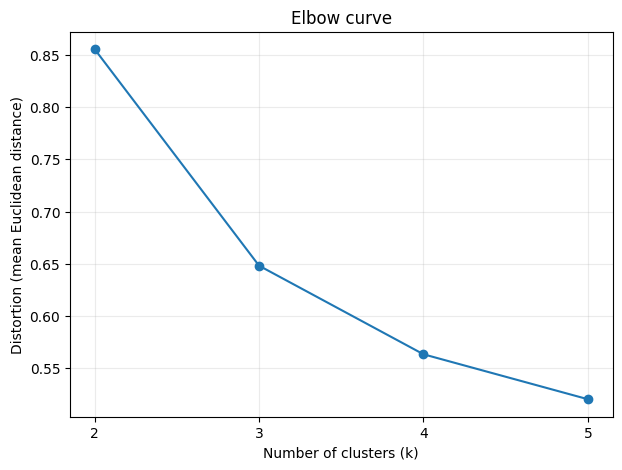

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(K, distortions, marker="o")
plt.xticks(K)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (mean Euclidean distance)")
plt.title("Elbow curve")
plt.grid(True, alpha=0.25)
plt.show()


#### Part 8 -  Implementing K-means clustering with scikit learn

In [9]:
from sklearn.cluster import KMeans as sklKMeans
from sklearn.metrics import silhouette_score as sk_silhouette_score

In [10]:
k = 3
sk_kmeans = sklKMeans(
    n_clusters=k,
    init="random",
    n_init=10,
    random_state=0,
)
sk_kmeans.fit(train_x)

ss = sk_silhouette_score(train_x, sk_kmeans.labels_)
dist = distortion(train_x, sk_kmeans.labels_, sk_kmeans.cluster_centers_)

print(f"scikit-learn silhouette score: {ss:.5f}")
print(f"scikit-learn distortion: {dist:.5f}")

my_sil = silhouette_score(train_x, kmeans.labels)
my_dist = distortion(train_x, kmeans.labels, kmeans.centroids)
print(f"From-scratch silhouette score: {my_sil:.5f}")
print(f"From-scratch distortion: {my_dist:.5f}")
print(f"Silhouette difference: {abs(ss - my_sil):.5f}")
print(f"Distortion difference: {abs(dist - my_dist):.5f}")


scikit-learn silhouette score: 0.55282
scikit-learn distortion: 0.64803
From-scratch silhouette score: 0.55282
From-scratch distortion: 0.64803
Silhouette difference: 0.00000
Distortion difference: 0.00000


## b) Clustering using Gaussian Mixture Model(GMM)

### Program 1 — Implementing a GMM from scratch using the Expectation–Maximization algorithm

#### AIM

To implement a Gaussian Mixture Model (GMM) from scratch using the Expectation–Maximization (EM) algorithm and compare two methods for initializing the component means.

#### Formula:

##### Log-likelihood

For $K$ Gaussian components, the observed-data log-likelihood is

$$
\ell(\theta)=\sum_{i=1}^{N}\log\left[\sum_{k=1}^{K}\pi_k\,
\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)\right].
$$

##### Auxiliary function

$$
Q(\theta,\theta^{(t-1)})=
\sum_i\sum_k r_{ik}\log\pi_k+
\sum_i\sum_k r_{ik}\log p(\mathbf{x}_i\mid\theta_k),
$$

where $r_{ik}=p(z_i=k\mid\mathbf{x}_i,\theta^{(t-1)})$ is the responsibility that component $k$ takes for observation $i$.

##### Responsibility (E-step)

$$
r_{ik}=\frac{\pi_k\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)}
{\sum_{j=1}^{K}\pi_j\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j)}.
$$

For every observation $i$, the responsibilities must satisfy $\sum_k r_{ik}=1$.

##### Parameter updates (M-step)

Let $N_k=\sum_i r_{ik}$. Then

$$
\pi_k=\frac{N_k}{N},\qquad
\boldsymbol{\mu}_k=\frac{\sum_i r_{ik}\mathbf{x}_i}{N_k},\qquad
\boldsymbol{\Sigma}_k=
\frac{\sum_i r_{ik}(\mathbf{x}_i-\boldsymbol{\mu}_k)(\mathbf{x}_i-\boldsymbol{\mu}_k)^T}{N_k}.
$$

#### EM algorithm

1. Initialize the component weights, means, and covariance matrices.
2. **E-step:** calculate the posterior responsibility of every component for every observation.
3. **M-step:** update the weights, means, and covariance matrices using those responsibilities.
4. Evaluate the log-likelihood and repeat steps 2–3 until its improvement is no greater than the tolerance.

#### Part 1 - Defining the class for GMM

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans as SklKMeans

In [20]:
class GMM:
    def __init__(
        self, n_components: int, n_iters: int, tol: float,
        random_state: int = 0, init_params: str = "random",
        reg_covar: float = 1e-6,
    ):
        self.n_components = n_components
        self.n_iters = n_iters
        self.tol = tol
        self.init_params = init_params
        self.random_state = random_state
        self.reg_covar = reg_covar

    def fit(self, X, plot=False, plot_params=None):
        if plot_params is None:
            plot_params = {}

        X = np.asarray(X)
        m, n = X.shape
        self.X = X
        k = self.n_components
        rng = np.random.default_rng(self.random_state)

        self.resp = np.zeros((m, k))
        self.weights = np.full(k, 1 / k)


        if self.init_params == "kmeans":
            km = SklKMeans(n_clusters=k, init="random", n_init=10, random_state=self.random_state)
            km.fit(X)
            self.means = km.cluster_centers_.copy()
        elif self.init_params == "random":
            indices = rng.choice(m, size=k, replace=False)
            self.means = X[indices].copy()
        else:
            raise ValueError(f"Unsupported init_params: {self.init_params}")


        base_cov = np.atleast_2d(np.cov(X, rowvar=False))
        base_cov = base_cov + self.reg_covar * np.eye(n)
        self.covs = np.repeat(base_cov[None, :, :], k, axis=0)

        self.converged = False
        self.log_likelihood_trace = []

        if plot:
            fig, ax = plt.subplots(1, 4, figsize=(20, 5))
            fig.suptitle("GMM using Expectation–Maximization")
            self.draw(ax[0], "Initial components", **plot_params)

        for iteration in range(self.n_iters):

            log_likelihood = self._do_estep(X)
            self._do_mstep(X)

            log_likelihood = self._do_estep(X)


            self.log_likelihood_trace.append(log_likelihood)

            if iteration == 0 and plot:
                self.draw(ax[1], "Components after 1 iteration", **plot_params)

            if iteration > 0:
                old_ll, new_ll = self.log_likelihood_trace[-2:]

                improvement = new_ll - old_ll
                if improvement >= 0 and improvement <= self.tol:
                    self.converged = True
                    break

        self.n_iter_ = iteration + 1

        if plot:
            self.draw(ax[2], f"Components after {self.n_iter_} iterations", **plot_params)
            ax[3].plot(self.log_likelihood_trace, "-o")
            ax[3].set_title("Log-likelihood")
            ax[3].set_xlabel("Iteration")
            plt.show()

        return self

    def _do_estep(self, X):
        X = np.asarray(X)
        m = X.shape[0]
        k = self.n_components
        unnormalized = np.zeros((m, k))

        for j in range(k):
            unnormalized[:, j] = self.weights[j] * multivariate_normal(
                mean=self.means[j], cov=self.covs[j], allow_singular=False
            ).pdf(X)

        row_sums = np.maximum(unnormalized.sum(axis=1), 1e-300)
        self.resp = unnormalized / row_sums[:, None]


        log_likelihood = np.sum(np.log(row_sums))
        return log_likelihood

    def _do_mstep(self, X):
        X = np.asarray(X)
        m, n = X.shape


        resp_weights = self.resp.sum(axis=0)
        resp_weights = np.maximum(resp_weights, 1e-12)
        self.weights = resp_weights / m


        self.means = (self.resp.T @ X) / resp_weights[:, None]


        self.covs = np.empty((self.n_components, n, n))
        for j in range(self.n_components):
            centered = X - self.means[j]
            weighted = centered * self.resp[:, j][:, None]
            cov = (weighted.T @ centered) / resp_weights[j]
            self.covs[j] = cov + self.reg_covar * np.eye(n)

    def predict_proba(self, X):

        X = np.asarray(X)
        unnormalized = np.zeros((X.shape[0], self.n_components))
        for j in range(self.n_components):
            unnormalized[:, j] = self.weights[j] * multivariate_normal(
                mean=self.means[j], cov=self.covs[j], allow_singular=False
            ).pdf(X)
        row_sums = np.maximum(unnormalized.sum(axis=1), 1e-300)
        return unnormalized / row_sums[:, None]

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def draw(self, ax, title="", **plot_params):
        ax.set_title(title)
        ax.scatter(self.X[:, 0], self.X[:, 1], **plot_params)

        delta = 0.05
        x = np.arange(*ax.get_xlim(), delta)
        y = np.arange(*ax.get_ylim(), delta)
        x, y = np.meshgrid(x, y)
        colors = [f"C{(i + 1) % 10}" for i in range(self.n_components)]

        for i in range(self.n_components):
            mean, cov = self.means[i], self.covs[i]
            z = multivariate_normal(mean, cov).pdf(np.dstack([x, y]))
            ax.scatter(mean[0], mean[1], color=colors[i], marker="X", s=100)
            ax.contour(x, y, z, levels=[0.01], colors=colors[i])


#### Part 2 — Generating random data from a Gaussian mixture

The data-generation function is supplied. Read it carefully and identify where the means and positive-semidefinite covariance matrices are created.

In [13]:
def gen_data(k=3, dim=2, points_per_cluster=200, lim=(-10, 10), seed=1):
    rng = np.random.default_rng(seed)
    samples = np.empty((k, points_per_cluster, dim))
    means = rng.uniform(lim[0], lim[1], size=(k, dim))

    for i in range(k):
        A = rng.random((dim, dim + 10))
        cov = A @ A.T
        samples[i] = rng.multivariate_normal(means[i], cov, points_per_cluster)

    X = samples.reshape(-1, dim)

    if dim == 2:
        plt.figure(figsize=(6, 5))
        plt.title("Generated Gaussian-mixture data")
        plt.scatter(X[:, 0], X[:, 1], s=3, alpha=0.4)
        plt.show()

    return X

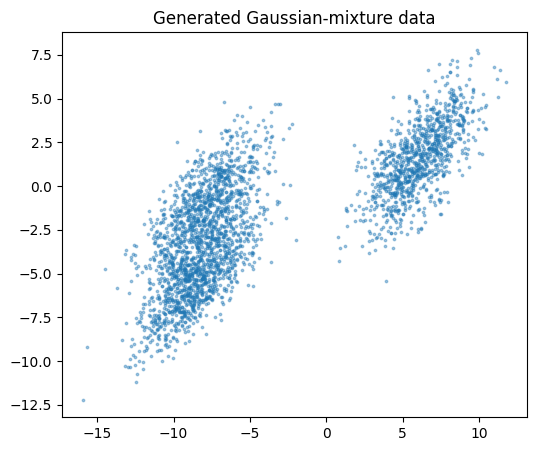

In [16]:
X = gen_data(k=3, dim=2, points_per_cluster=1000, seed=3)

#### Part 3 - Implementing GMM on generated random data

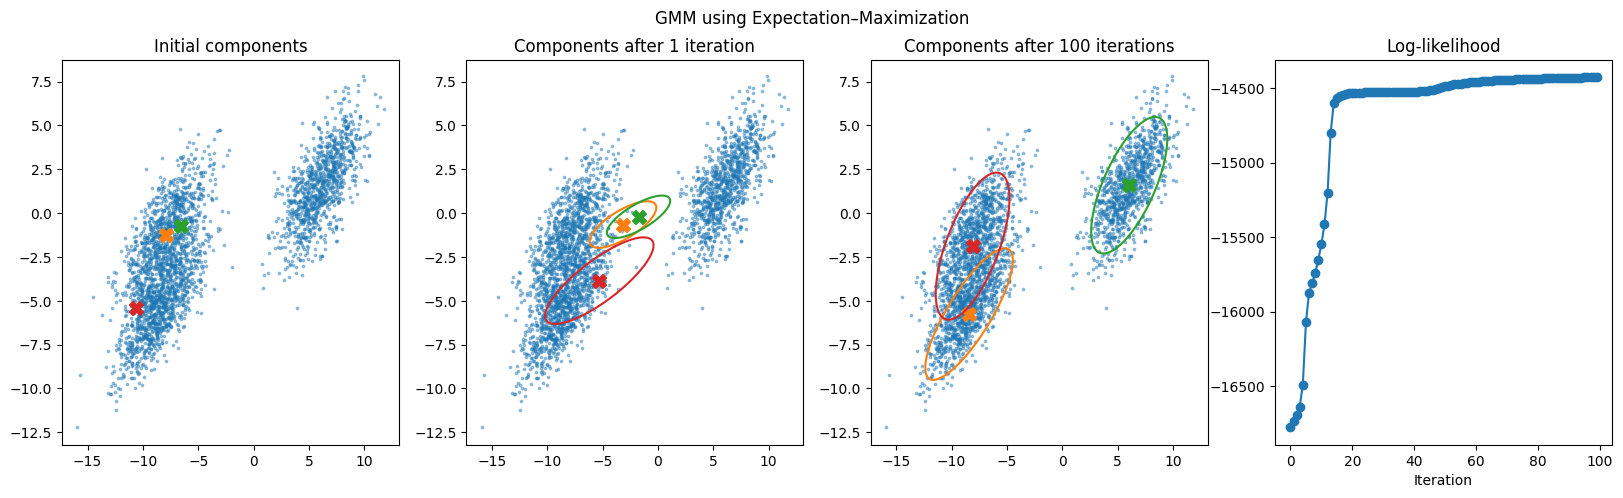

In [17]:
# Create a 3-component GMM with random initialization, fit it to X,
# and display the progress plots. Use n_iters=100, tol=1e-4, random_state=5.
gmm_random = GMM(
    n_components=3,
    n_iters=100,
    tol=1e-4,
    random_state=5,
    init_params="random",
)
gmm_random.fit(X, plot=True, plot_params={"s": 3, "alpha": 0.4})

assert np.allclose(gmm_random.weights.sum(), 1.0)
assert np.allclose(gmm_random.resp.sum(axis=1), 1.0)
assert np.all(np.diff(gmm_random.log_likelihood_trace) >= -1e-6)


#### Part 4 - Implementing GMM by using kmeans to initialize means

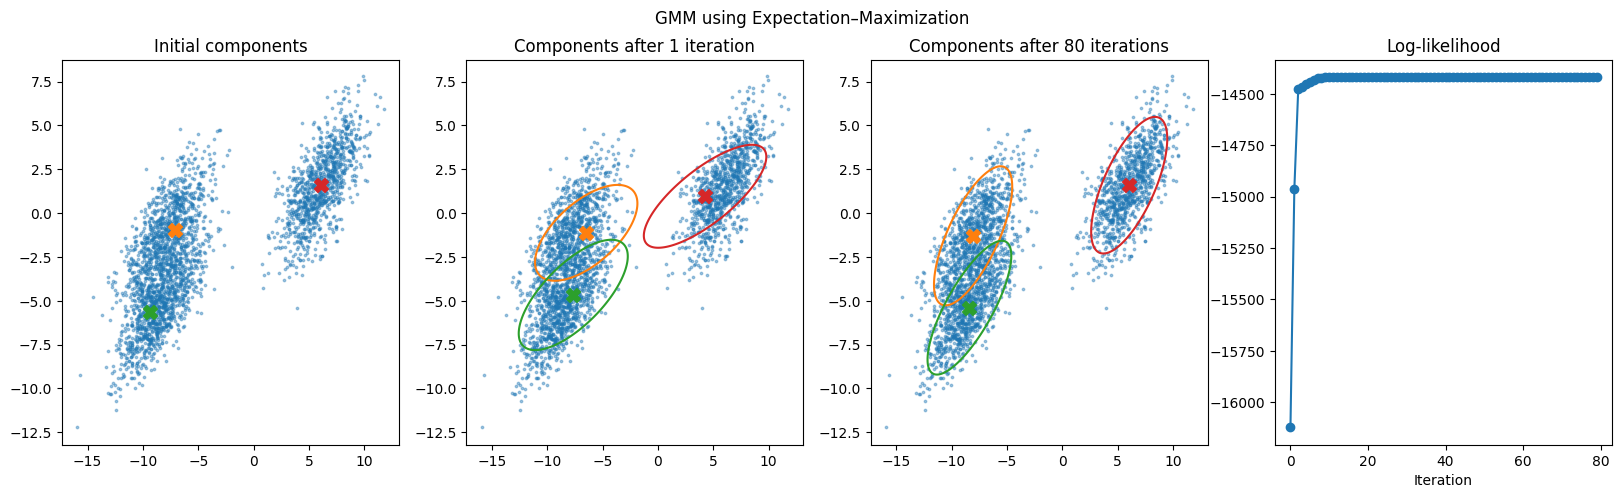

Random initialization: 100 iterations, final log-likelihood = -14425.81985
K-means initialization: 80 iterations, final log-likelihood = -14419.11868
Faster convergence: K-means initialization
Final log-likelihood difference: 6.701174239738975


In [18]:
# Repeat the fit with K-means initialization and random_state=1.
gmm_kmeans = GMM(
    n_components=3,
    n_iters=100,
    tol=1e-4,
    random_state=1,
    init_params="kmeans",
)
gmm_kmeans.fit(X, plot=True, plot_params={"s": 3, "alpha": 0.4})


print(f"Random initialization: {gmm_random.n_iter_} iterations, final log-likelihood = {gmm_random.log_likelihood_trace[-1]:.5f}")
print(f"K-means initialization: {gmm_kmeans.n_iter_} iterations, final log-likelihood = {gmm_kmeans.log_likelihood_trace[-1]:.5f}")
if gmm_random.n_iter_ < gmm_kmeans.n_iter_:
    faster = "random initialization"
elif gmm_kmeans.n_iter_ < gmm_random.n_iter_:
    faster = "K-means initialization"
else:
    faster = "both runs (tie)"
print("Faster convergence:", faster)
print("Final log-likelihood difference:", abs(gmm_random.log_likelihood_trace[-1] - gmm_kmeans.log_likelihood_trace[-1]))


## Results and interpretation

1. **Best value of $k$ for Iris:** The silhouette scores were 0.68105 ($k=2$), 0.55282 ($k=3$), 0.49403 ($k=4$), and 0.36780 ($k=5$). Therefore, the silhouette metric alone favours $k=2$, while the known Iris dataset has three species and the elbow curve shows a substantial reduction in distortion through $k=3$. Thus $k=3$ is a reasonable choice when combining the elbow evidence with the known three-species structure, even though the silhouette score itself is highest at $k=2$.

2. **From-scratch vs scikit-learn K-means:** For $k=3$, both implementations produced a silhouette score of **0.55282** and distortion of **0.64803**. The differences were 0.00000 for both metrics, showing that the from-scratch implementation reproduces the scikit-learn result for this initialization and convergence setting.

3. **Random vs K-means initialization for GMM:** Random initialization ran for **100 iterations** with final log-likelihood **-14425.81985**, while K-means initialization converged in **80 iterations** with final log-likelihood **-14419.11868**. Thus K-means initialization converged faster and reached a higher final log-likelihood. The final values are not identical, so the two initializations did not reach exactly the same solution.

4. **K-means vs GMM:** K-means gives each observation one hard cluster label, whereas GMM gives each observation a probability (responsibility) for every component. GMM can therefore represent uncertainty and overlapping clusters more naturally.

5. **Chemistry connection:** A GMM could be useful for a chemical dataset containing overlapping populations, such as molecular conformer populations described by spectroscopic or molecular-descriptor features. A molecule can have substantial probability of belonging to more than one overlapping population, which is captured by probabilistic responsibilities rather than a single hard K-means label.
